In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path 
import os
os.environ['MUJOCO_GL'] = 'egl'
os.environ['MKL_SERVICE_FORCE_INTEL'] = '1'
from tqdm import tqdm
from IPython.display import Video

import torch
import numpy as np

import sys
sys.path.append("/mnt/home/focus")

os.chdir("/mnt/home/focus")
print(f"Working directory: {os.getcwd()}")

import env
from env.make import make

import matplotlib.pyplot as plt
import matplotlib.animation as animation

/opt/conda/lib/python3.11/site-packages/robosuite/__init__.py:7: DeprecationWarning: The 'warn' method is deprecated, use 'warning' instead
  ROBOSUITE_DEFAULT_LOGGER.warn("No private macro file found!")
[robosuite WARNING] No private macro file found! (__init__.py:7)
[robosuite WARNING] It is recommended to use a private macro file (__init__.py:8)
[robosuite WARNING] To setup, run: python /opt/conda/lib/python3.11/site-packages/robosuite/scripts/setup_macros.py (__init__.py:9)


Working directory: /mnt/home/focus


/opt/conda/lib/python3.11/site-packages/warp_maniskill/warp/codegen.py:13: DeprecationWarning: the imp module is deprecated in favour of importlib and slated for removal in Python 3.12; see the module's documentation for alternative uses
  import imp
/opt/conda/lib/python3.11/site-packages/timm/models/layers/__init__.py:49: DeprecationWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", DeprecationWarning)


In [2]:
from hydra import compose, initialize
from omegaconf import OmegaConf

initialize(config_path="../../../../public/projects/mazpie/online_reacher_benchmark_1/pretrain/318a11550ec6f5c89516b04dfc3756f2/code/exp_local/2024.03.12/175058_dreamer_reacher_hard_/.hydra", job_name="config")
cfg = compose(config_name="config")

/tmp/ipykernel_5773/2565536518.py:4: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  initialize(config_path="../../../../public/projects/mazpie/online_reacher_benchmark_1/pretrain/318a11550ec6f5c89516b04dfc3756f2/code/exp_local/2024.03.12/175058_dreamer_reacher_hard_/.hydra", job_name="config")


In [3]:
global_step = 0
action_repeat = 2
snapshot_ts = global_step * action_repeat
seed = 0

domain = "dmc"  
task = "reacher_hard"

# Env creation
env = make(cfg.domain, cfg.task, action_repeat=action_repeat, seed=seed, env_config=cfg.env)

env.reset()

{'reward': 0.0,
 'is_first': True,
 'is_last': False,
 'is_terminal': False,
 'rgb': array([[[ 37,  37,  38, ...,  38,  38,  37],
         [ 38,  39,  39, ...,  73,  73,  38],
         [ 38,  39,  39, ...,  74,  73,  38],
         ...,
         [ 38,  73,  73, ...,  39,  39,  38],
         [ 37,  72,  73, ...,  39,  39,  37],
         [ 37,  37,  38, ...,  38,  37,  37]],
 
        [[ 62,  62,  62, ...,  62,  62,  62],
         [ 62,  78,  78, ..., 110, 110,  62],
         [ 62,  78,  78, ..., 112, 110,  62],
         ...,
         [ 62, 110, 111, ...,  78,  78,  62],
         [ 62, 110, 110, ...,  78,  78,  62],
         [ 62,  62,  62, ...,  62,  62,  62]],
 
        [[ 86,  86,  87, ...,  87,  86,  86],
         [ 86, 115, 115, ..., 149, 149,  86],
         [ 87, 115, 115, ..., 150, 149,  87],
         ...,
         [ 87, 149, 150, ..., 115, 115,  87],
         [ 86, 148, 149, ..., 115, 115,  86],
         [ 86,  86,  87, ...,  87,  86,  86]]], dtype=uint8),
 'proprio': array([     

In [4]:
# Import agent model (WM + Actor Critic)
# agent_path = Path(f'/mnt/public/projects/mazpie/focus_skill_dmc_sweep_distance_mode_coordConv/pretrained_models/skill_focus/dmc/reacher_hard/1/snapshot_500000.pt')
# agent_path = Path(f'/mnt/home/focus/exp_local/2024.01.23/144211_dreamer_reacher_hard_/last_snapshot.pt')
agent_path = Path(f'/mnt/public/projects/mazpie/online_reacher_benchmark_1/pretrain/318a11550ec6f5c89516b04dfc3756f2/code/last_snapshot.pt')

def load_agent(agent_path):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    with agent_path.open('rb') as f:
        obj = torch.load(f, map_location=torch.device(device))
        agent = obj['agent']    
        step = obj['_global_step']
    return agent, step

def init_agent(cfg):
    from utils import make_dreamer_agent
    return make_dreamer_agent(env.obs_space, env.action_spec(), cfg, cfg.agent)

# agent = init_agent(cfg)
agent = load_agent(agent_path)[0]

device = 'cuda' if torch.cuda.is_available() else 'cpu'
agent.device = device
agent.wm.device = device
agent.wm.rssm.device = device
agent.wm.rssm._cell.device = device
agent.is_finetune = True
agent.wm.rssm._full_posterior = True
agent.cfg.agent.only_expl_during_training = False

In [5]:
from replay_buffer import ReplayBuffer, make_replay_loader
from env.utils import obs_specs
from dm_env import specs

train_obs_spec = env.obs_space

meta_specs = agent.get_meta_specs()

data_specs = (*obs_specs(train_obs_spec),
            env.action_spec(),
            specs.Array((1,), np.float32, "reward"),
            specs.Array((1,), np.float32, "discount"))

# cfg.dataset_dir = "/mnt/public/projects/mazpie/online_reacher_benchmark_1/pretrain/861fcdbba354d1d39ed21ec4a6201d73/code/buffer""

# create data storage and load data
replay_storage = ReplayBuffer(
    data_specs,
    meta_specs,
    Path(cfg.dataset_dir),
    length=cfg.batch_length,
    **cfg.replay,
    device=cfg.device,
    load_first=True
)

# create replay buffer
replay_loader = make_replay_loader(
    replay_storage,
    cfg.batch_size,
    cfg.replay_buffer_num_workers,
)

Incosistency between min/max/length in the replay buffer. Defaulting to (length):  32


0.6884548 0.0
0.8828249 0.0
0.85542977 0.0


0.85111344 0.0
0.86883247 0.0


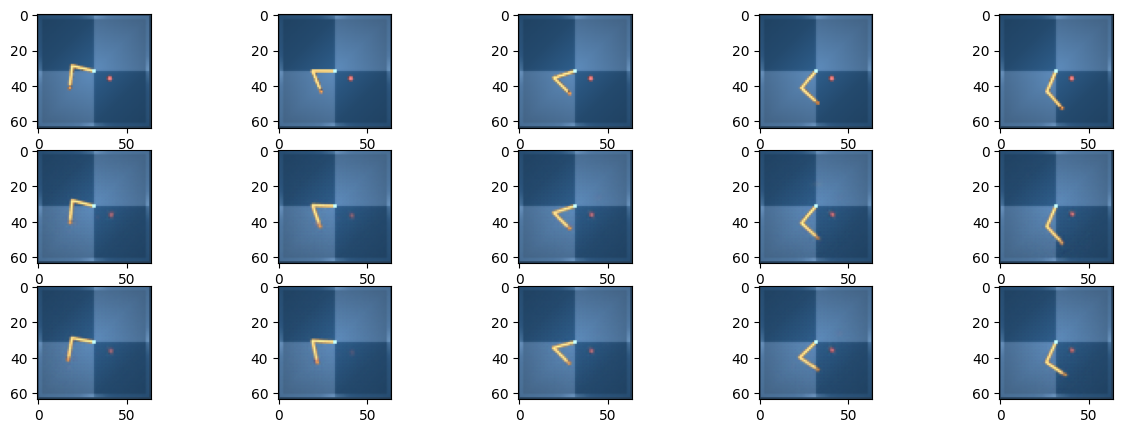

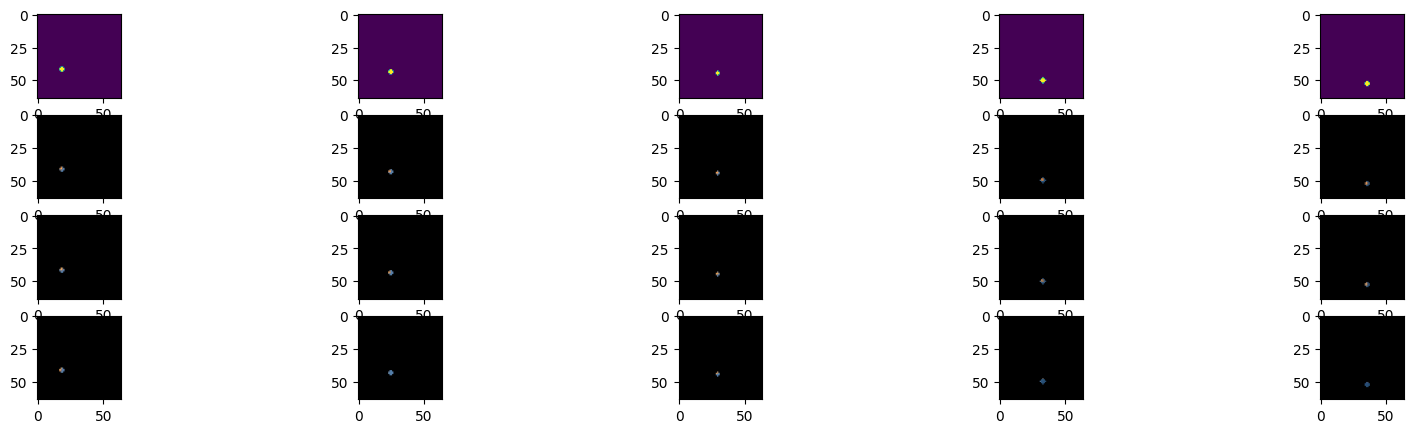

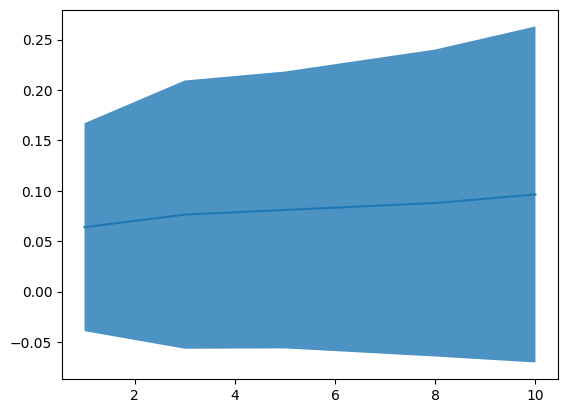

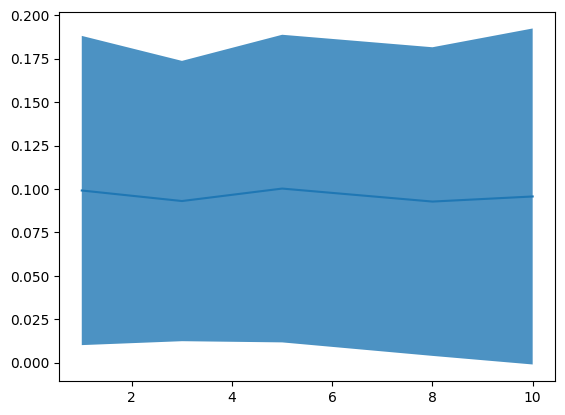

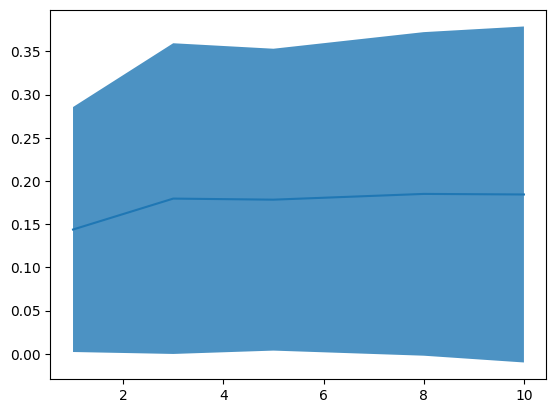

In [11]:
from scipy import ndimage
import matplotlib.pyplot as plt

feat = []
recon = []
agent_state = None
obs = env.reset()

tensor_obs = {
    k: torch.as_tensor(np.copy(v), device=agent.device).unsqueeze(0).unsqueeze(0)
    for k, v in obs.items()
}

data = agent.wm.preprocess(next(iter(replay_loader)))
metrics = agent.wm.RSSM_errors(data)
truth = data["rgb"] + 0.5
metrics = {"prior_error": [], "prior_recon_error": {"mean": [], "std": []}, "recon_masked_error": {"mean": [], "std": []}, "prior_recon_masked_error": {"mean": [], "std": []}}
imag_start_step = 5
error_steps = [1, 3, 5, 8, 10]

def det(t):
    return t.detach().cpu().numpy()

def mean_std(t):
    if isinstance(t, torch.Tensor):
        t = t.detach().cpu().numpy()
        
    mean = np.nanmean(np.where(np.isclose(t,0, atol=1e-2), np.nan, t))
    std = np.nanstd(np.where(np.isclose(t,0, atol=1e-2), np.nan, t))
    return {"mean": mean, "std": std}

fig1, axs1 = plt.subplots(3, len(error_steps), figsize=(15, 5))
fig2, axs2 = plt.subplots(4, len(error_steps), figsize=(20, 5))

with torch.no_grad():
    # initialize latent state for each observation, fake zero action
    decoder = agent.wm.heads["decoder"]  # B, T, C, H, W
    embed = agent.wm.encoder(data)
    
    post, prior = agent.wm.rssm.observe(
        embed,
        data["action"],
        data["is_first"],
    )

    recon = decoder(agent.wm.rssm.get_feat(post))["rgb"].mean + 0.5
    init = {k: v[:, imag_start_step] for k, v in post.items()}
    for i, s in enumerate(error_steps):
        # mse errors in the predictions
        pred_prior = agent.wm.rssm.imagine(data["action"][:, imag_start_step:imag_start_step+s], init)
        prior_recon = decoder(agent.wm.rssm.get_feat(pred_prior))["rgb"].mean + 0.5
        
        prior_error = torch.abs(agent.wm.rssm.get_feat(pred_prior)[:, -1] - agent.wm.rssm.get_feat(prior)[:, imag_start_step + s])
        metrics["prior_error"].append(mean_std(prior_error))
        
        prior_recon_error = torch.abs((prior_recon[:, -1]) - truth[:, imag_start_step + s])
        prior_recon_error_metrics = mean_std(prior_recon_error)
        
        metrics["prior_recon_error"]["mean"].append(prior_recon_error_metrics["mean"])
        metrics["prior_recon_error"]["std"].append(prior_recon_error_metrics["std"])
        
        # mse objects errors in the predictions
        # Mask of object -> dilate mask -> compute mse over selected region
        if "segmentation" in data.keys():
            seg = data["segmentation"][:,:,0]
            struct = np.array([[[[0, 1, 0], [1, 1, 1], [0, 1, 0]]]])
            dilated_seg = ndimage.binary_dilation(seg.detach().cpu().numpy(), struct, iterations=1)
            dilated_seg_rgb_axis = np.repeat(dilated_seg[:, imag_start_step + s, np.newaxis], 3, axis=1)
            
            truth_masked = truth[:, imag_start_step + s].detach().cpu().numpy() * dilated_seg_rgb_axis
            recon_masked = recon[:, imag_start_step + s].detach().cpu().numpy() * dilated_seg_rgb_axis
            prior_recon_masked = prior_recon[:, -1].detach().cpu().numpy() * dilated_seg_rgb_axis

            recon_masked_error = np.abs(truth_masked - recon_masked)  # mean over the mask
            # recon_masked_metrics = {"mean": np.sum(recon_masked_error) / (np.sum(dilated_seg_rgb_axis)) ,"std": np.nanstd(np.where(np.equal(recon_masked_error,0), np.nan, prior_recon_masked_error))}
            recon_masked_metrics = mean_std(recon_masked_error)
            metrics["recon_masked_error"]["mean"].append(recon_masked_metrics["mean"])
            metrics["recon_masked_error"]["std"].append(recon_masked_metrics["std"])
        
                    
            prior_recon_masked_error = np.abs(truth_masked - prior_recon_masked)  # mean over the mask
            # prior_recon_masked_metrics = {"mean": np.sum(prior_recon_masked_error) / (np.sum(dilated_seg_rgb_axis)) ,"std": np.nanstd(np.where(np.equal(prior_recon_masked_error,0), np.nan, prior_recon_masked_error))}
            prior_recon_masked_metrics = mean_std(prior_recon_masked_error)
            print(prior_recon_masked_error.max(), prior_recon_masked_error.min())
            metrics["prior_recon_masked_error"]["mean"].append(prior_recon_masked_metrics["mean"])
            metrics["prior_recon_masked_error"]["std"].append(prior_recon_masked_metrics["std"])
        
        axs1[0, i].imshow(det(truth[0, imag_start_step + s].permute(1,2,0)))
        axs1[1, i].imshow(det(recon[0, imag_start_step + s].permute(1,2,0)))
        axs1[2, i].imshow(det(prior_recon[0, -1].permute(1,2,0)))
        
        axs2[0, i].imshow(dilated_seg[0][imag_start_step + s])
        axs2[1, i].imshow(truth_masked[0].transpose(1,2,0))
        axs2[2, i].imshow(recon_masked[0].transpose(1,2,0))
        axs2[3, i].imshow(prior_recon_masked[0].transpose(1,2,0))

plt.figure()
plt.plot(error_steps, metrics["prior_recon_error"]["mean"])
plt.fill_between(error_steps, np.subtract(metrics["prior_recon_error"]["mean"], metrics["prior_recon_error"]["std"]), np.add(metrics["prior_recon_error"]["mean"], metrics["prior_recon_error"]["std"]), alpha=0.8)

plt.figure()
plt.plot(error_steps, metrics["recon_masked_error"]["mean"])
plt.fill_between(error_steps, np.subtract(metrics["recon_masked_error"]["mean"], metrics["recon_masked_error"]["std"]), np.add(metrics["recon_masked_error"]["mean"], metrics["recon_masked_error"]["std"]), alpha=0.8)

plt.figure()
plt.plot(error_steps, metrics["prior_recon_masked_error"]["mean"])
plt.fill_between(error_steps, np.subtract(metrics["prior_recon_masked_error"]["mean"], metrics["prior_recon_masked_error"]["std"]), np.add(metrics["prior_recon_masked_error"]["mean"], metrics["prior_recon_masked_error"]["std"]), alpha=0.8)
